# Conversion Analysis: Contact Group, Response Time & MMR Impact

**Dataset:** Conversion Data Nov-Dec 2025 (68,360 records)

**Objective:** Understand conversion rate differences between contact groups (COUNTER, HRD-OKC, NO CONTACT) and the impact of response time and MMR status.

In [2]:
# Setup and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONSULTING-STYLE CHART SETTINGS
# ============================================================
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Color palette (consulting-style)
COLORS = {
    'primary': '#2E5090',      # Deep blue
    'secondary': '#E85D4C',    # Coral red
    'tertiary': '#5FAD56',     # Green
    'neutral': '#8B8B8B',      # Gray
    'light': '#B8D4E8',        # Light blue
    'highlight': '#F4B942',    # Gold/yellow
    'mmr': '#2E5090',          # Blue for MMR
    'no_mmr': '#E85D4C',       # Red for NO MMR
    'counter': '#2E5090',      # Blue for COUNTER
    'hrd': '#E85D4C',          # Red for HRD-OKC
    'no_contact': '#8B8B8B',   # Gray for NO CONTACT
}

def format_pct(x, pos):
    return f'{x:.0f}%'

def format_thousands(x, pos):
    return f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}'

# Load the dataset
df = pd.read_excel('../data/raw/Conversion Data Nov-Dec 2025 (1).xlsx', engine='openpyxl')

# Clean column names (remove leading newlines)
df.columns = df.columns.str.strip().str.replace('\n', '')

# Define key columns
CONTACT_GROUP = 'CONTACT_GROUP'
CONTACT_RANGE = 'CONTACT RANGE'
RENT_IND = 'RENT_IND'
MMR = 'MMR'

# Define range order for consistent display
RANGE_ORDER = [
    '(a)<30min', '(b)31min - 1hr', '(c)1-3 hrs', '(d)3-6 hrs',
    '(e)6-12 hrs', '(f)12-24 hrs', '(g)24-48 hrs', '(h)48+ hrs', 'NO CONTACT'
]

# Short labels for charts
RANGE_LABELS = ['<30m', '30m-1h', '1-3h', '3-6h', '6-12h', '12-24h', '24-48h', '48h+', 'None']

print(f"✓ Dataset loaded: {len(df):,} records")
print(f"✓ Visualization settings configured")

✓ Dataset loaded: 68,360 records
✓ Visualization settings configured


---
## Analysis 1: Conversion Rate by Contact Group and Response Time Range

### Hypothesis
Different contact groups (COUNTER, HRD-OKC, NO CONTACT) have different conversion rates, and response time affects conversion within each group.

### Summary Approach
1. Calculate overall conversion rate by contact group
2. Break down conversion by response time range within each contact group
3. Compare COUNTER vs HRD-OKC head-to-head at each time range

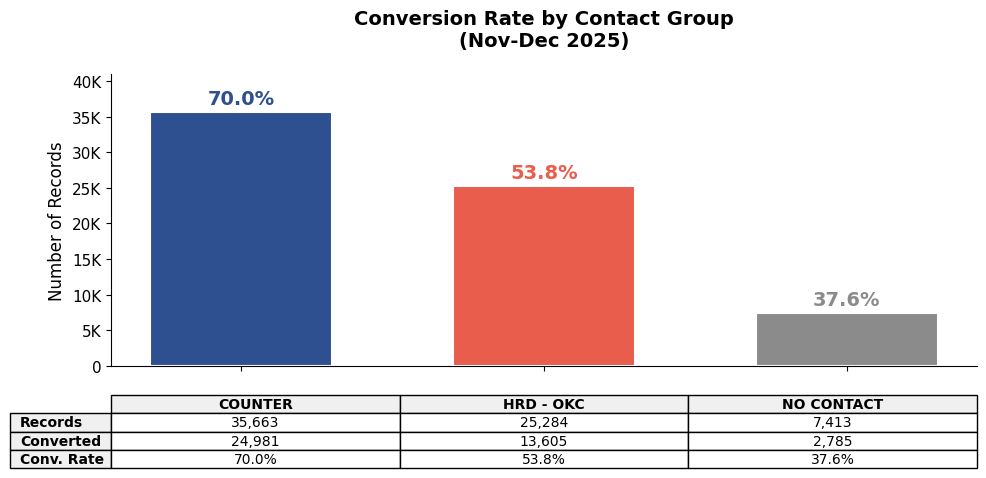


KEY INSIGHT: COUNTER outperforms HRD-OKC by +16.2 pts
             Being contacted beats NO CONTACT by +16-32 pts


In [3]:
# Analysis 1: Overall Conversion by Contact Group
# ============================================================

# Calculate metrics
group_summary = df.groupby(CONTACT_GROUP).agg(
    records=(RENT_IND, 'count'),
    converted=(RENT_IND, 'sum'),
    conv_rate=(RENT_IND, 'mean')
).reset_index()
group_summary['conv_rate_pct'] = group_summary['conv_rate'] * 100

# Sort by conversion rate descending
group_order = ['COUNTER', 'HRD - OKC', 'NO CONTACT']
group_summary['sort_order'] = group_summary[CONTACT_GROUP].apply(lambda x: group_order.index(x))
group_summary = group_summary.sort_values('sort_order')

# Create figure with bar chart + data table
fig, ax = plt.subplots(figsize=(10, 5))

# Bar colors
bar_colors = [COLORS['counter'], COLORS['hrd'], COLORS['no_contact']]

# Plot bars (records/volume)
bars = ax.bar(group_summary[CONTACT_GROUP], group_summary['records'], 
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)

# Add conversion rate labels on bars
for i, (bar, rate) in enumerate(zip(bars, group_summary['conv_rate_pct'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold',
            color=bar_colors[i])

# Formatting
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_title('Conversion Rate by Contact Group\n(Nov-Dec 2025)', fontsize=14, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
ax.set_ylim(0, max(group_summary['records']) * 1.15)

# Add data table below
table_data = [
    [f"{int(r):,}" for r in group_summary['records']],
    [f"{int(c):,}" for c in group_summary['converted']],
    [f"{r:.1f}%" for r in group_summary['conv_rate_pct']]
]
row_labels = ['Records', 'Converted', 'Conv. Rate']

table = ax.table(cellText=table_data, rowLabels=row_labels,
                 colLabels=group_summary[CONTACT_GROUP].tolist(),
                 loc='bottom', bbox=[0.0, -0.35, 1.0, 0.25],
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
for key, cell in table.get_celld().items():
    if key[0] == 0:  # Header row
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#f0f0f0')
    if key[1] == -1:  # Row labels
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#f0f0f0')

plt.subplots_adjust(bottom=0.25)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

# Key insight callout
print("\n" + "="*70)
print("KEY INSIGHT: COUNTER outperforms HRD-OKC by +16.2 pts")
print("             Being contacted beats NO CONTACT by +16-32 pts")
print("="*70)

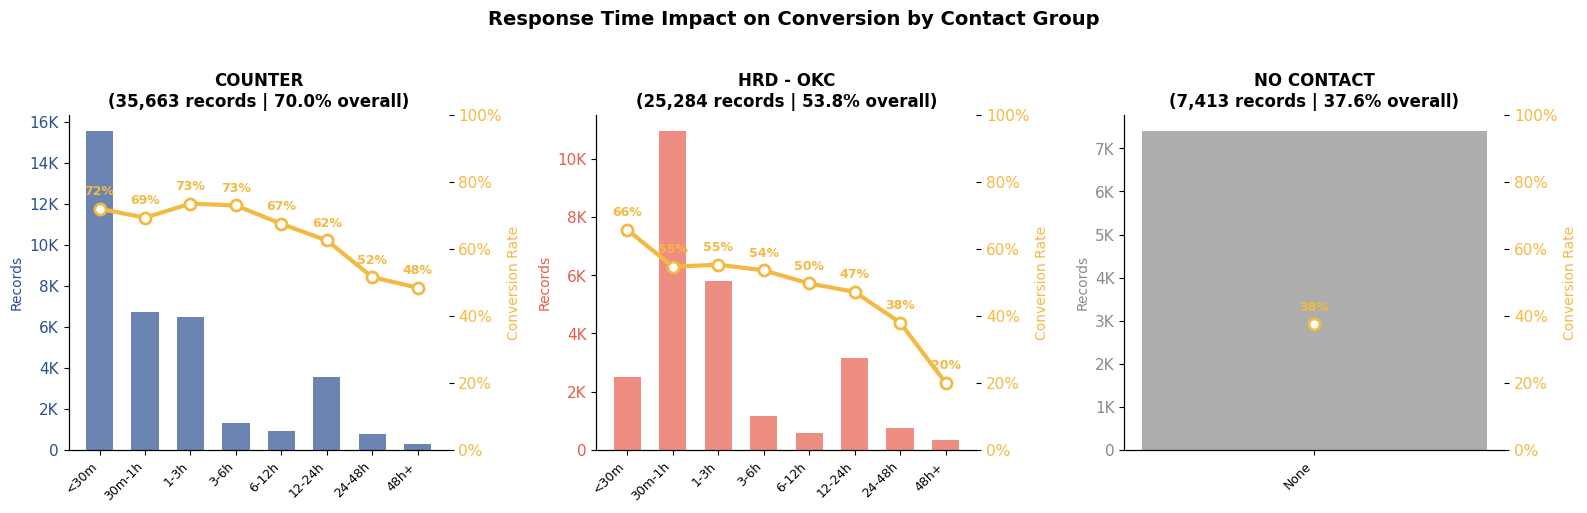


KEY INSIGHT: Speed matters more for HRD-OKC
  • HRD-OKC drops 45 pts from <30min (66%) to 48+hrs (20%)
  • COUNTER drops only 23 pts (72% to 48%)


In [4]:
# Analysis 1: Conversion by Response Time Range (Dual-Axis Charts)
# ============================================================
# Bars = Volume (absolute), Line = Conversion Rate (%)

def create_dual_axis_chart(df, group_name, color, ax):
    """Create dual-axis chart: bars for volume, line for conversion rate."""
    group_df = df[df[CONTACT_GROUP] == group_name]
    
    range_summary = group_df.groupby(CONTACT_RANGE).agg(
        records=(RENT_IND, 'count'),
        conv_rate=(RENT_IND, 'mean')
    ).reset_index()
    range_summary['conv_rate_pct'] = range_summary['conv_rate'] * 100
    
    # Sort by defined order
    range_summary['sort_order'] = range_summary[CONTACT_RANGE].apply(
        lambda x: RANGE_ORDER.index(x) if x in RANGE_ORDER else 99
    )
    range_summary = range_summary.sort_values('sort_order').reset_index(drop=True)
    
    x = np.arange(len(range_summary))
    
    # Primary axis: bars for volume
    bars = ax.bar(x, range_summary['records'], color=color, alpha=0.7, width=0.6)
    ax.set_ylabel('Records', color=color, fontsize=10)
    ax.tick_params(axis='y', labelcolor=color)
    ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
    
    # Secondary axis: line for conversion rate
    ax2 = ax.twinx()
    line = ax2.plot(x, range_summary['conv_rate_pct'], color=COLORS['highlight'], 
                    linewidth=3, marker='o', markersize=8, markerfacecolor='white',
                    markeredgecolor=COLORS['highlight'], markeredgewidth=2)
    ax2.set_ylabel('Conversion Rate', color=COLORS['highlight'], fontsize=10)
    ax2.tick_params(axis='y', labelcolor=COLORS['highlight'])
    ax2.yaxis.set_major_formatter(FuncFormatter(format_pct))
    ax2.set_ylim(0, 100)
    
    # Add rate labels on line points
    for i, (xi, rate) in enumerate(zip(x, range_summary['conv_rate_pct'])):
        ax2.annotate(f'{rate:.0f}%', (xi, rate), textcoords="offset points", 
                    xytext=(0, 10), ha='center', fontsize=9, fontweight='bold',
                    color=COLORS['highlight'])
    
    # X-axis labels
    labels = [RANGE_LABELS[RANGE_ORDER.index(r)] if r in RANGE_ORDER else r 
              for r in range_summary[CONTACT_RANGE]]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    
    # Title
    overall_conv = group_df[RENT_IND].mean() * 100
    ax.set_title(f'{group_name}\n({len(group_df):,} records | {overall_conv:.1f}% overall)', 
                 fontsize=12, fontweight='bold')
    
    return range_summary

# Create 3-panel figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Response Time Impact on Conversion by Contact Group', 
             fontsize=14, fontweight='bold', y=1.02)

groups = [('COUNTER', COLORS['counter']), ('HRD - OKC', COLORS['hrd']), ('NO CONTACT', COLORS['no_contact'])]
range_data = {}

for ax, (group, color) in zip(axes, groups):
    range_data[group] = create_dual_axis_chart(df, group, color, ax)

plt.tight_layout()
plt.show()

# Key insight
print("\n" + "="*70)
print("KEY INSIGHT: Speed matters more for HRD-OKC")
print("  • HRD-OKC drops 45 pts from <30min (66%) to 48+hrs (20%)")
print("  • COUNTER drops only 23 pts (72% to 48%)")
print("="*70)

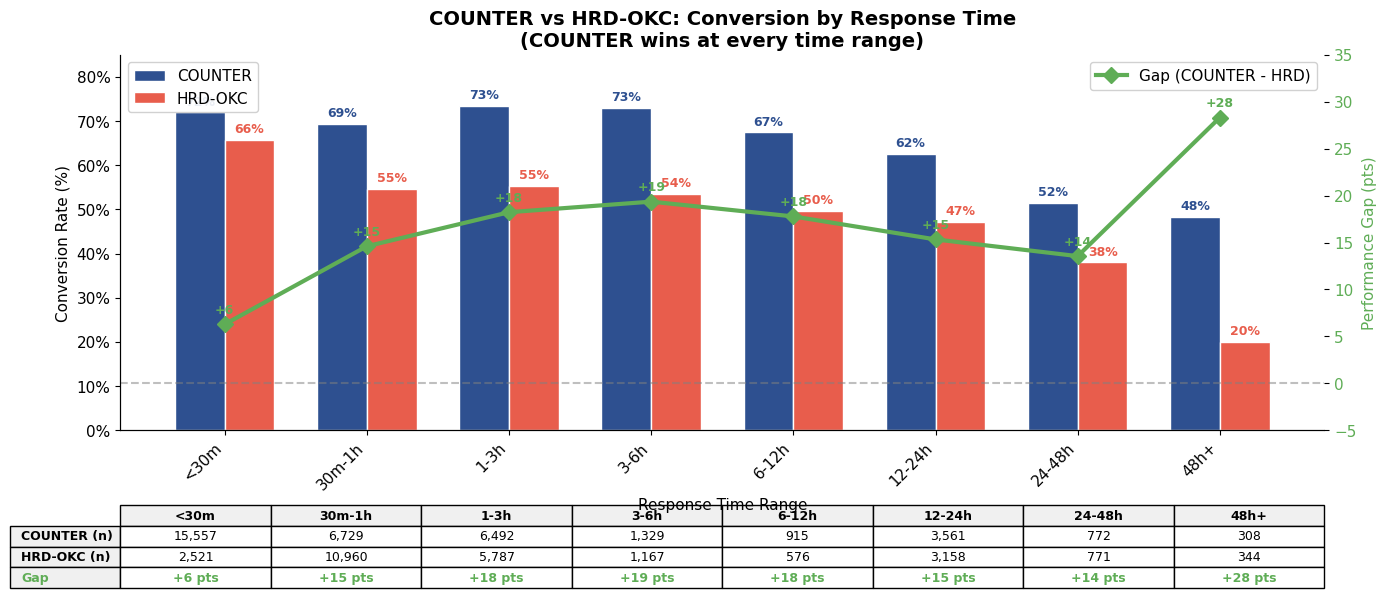


KEY INSIGHT: COUNTER beats HRD-OKC at EVERY time range
  • Gap ranges from +6 pts (<30min) to +28 pts (48+hrs)
  • Gap widens as response time increases


In [5]:
# Head-to-Head: COUNTER vs HRD-OKC by Response Time
# ============================================================

def prepare_comparison_data(df, group1, group2):
    """Prepare head-to-head comparison data."""
    results = []
    for range_val in RANGE_ORDER[:-1]:  # Exclude 'NO CONTACT'
        g1_data = df[(df[CONTACT_GROUP] == group1) & (df[CONTACT_RANGE] == range_val)]
        g2_data = df[(df[CONTACT_GROUP] == group2) & (df[CONTACT_RANGE] == range_val)]
        
        results.append({
            'range': range_val,
            f'{group1}_n': len(g1_data),
            f'{group1}_conv': g1_data[RENT_IND].mean() * 100 if len(g1_data) > 0 else np.nan,
            f'{group2}_n': len(g2_data),
            f'{group2}_conv': g2_data[RENT_IND].mean() * 100 if len(g2_data) > 0 else np.nan,
        })
    
    comparison = pd.DataFrame(results)
    comparison['diff'] = comparison[f'{group1}_conv'] - comparison[f'{group2}_conv']
    return comparison

comparison = prepare_comparison_data(df, 'COUNTER', 'HRD - OKC')

# Create grouped bar chart with gap line
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(comparison))
width = 0.35

# Bars for each group
bars1 = ax.bar(x - width/2, comparison['COUNTER_conv'], width, 
               label='COUNTER', color=COLORS['counter'], edgecolor='white')
bars2 = ax.bar(x + width/2, comparison['HRD - OKC_conv'], width, 
               label='HRD-OKC', color=COLORS['hrd'], edgecolor='white')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9, 
            color=COLORS['counter'], fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9,
            color=COLORS['hrd'], fontweight='bold')

# Secondary axis for gap
ax2 = ax.twinx()
gap_line = ax2.plot(x, comparison['diff'], color=COLORS['tertiary'], 
                    linewidth=3, marker='D', markersize=8, 
                    label='Gap (COUNTER - HRD)')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel('Performance Gap (pts)', color=COLORS['tertiary'], fontsize=11)
ax2.tick_params(axis='y', labelcolor=COLORS['tertiary'])
ax2.set_ylim(-5, 35)

# Add gap labels
for i, (xi, gap) in enumerate(zip(x, comparison['diff'])):
    ax2.annotate(f'+{gap:.0f}', (xi, gap), textcoords="offset points", 
                xytext=(0, 8), ha='center', fontsize=9, fontweight='bold',
                color=COLORS['tertiary'])

# Formatting
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.set_xlabel('Response Time Range', fontsize=11)
ax.set_title('COUNTER vs HRD-OKC: Conversion by Response Time\n(COUNTER wins at every time range)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(RANGE_LABELS[:-1], rotation=45, ha='right')
ax.set_ylim(0, 85)
ax.yaxis.set_major_formatter(FuncFormatter(format_pct))
ax.legend(loc='upper left', framealpha=0.9)
ax2.legend(loc='upper right', framealpha=0.9)

# Data table below
table_data = [
    [f"{int(n):,}" for n in comparison['COUNTER_n']],
    [f"{int(n):,}" for n in comparison['HRD - OKC_n']],
    [f"+{d:.0f} pts" for d in comparison['diff']]
]
row_labels = ['COUNTER (n)', 'HRD-OKC (n)', 'Gap']

table = ax.table(cellText=table_data, rowLabels=row_labels,
                 colLabels=RANGE_LABELS[:-1],
                 loc='bottom', bbox=[0.0, -0.42, 1.0, 0.22],
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
for key, cell in table.get_celld().items():
    if key[0] == 0 or key[1] == -1:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#f0f0f0')
    if key[0] == 3:  # Gap row
        cell.set_text_props(color=COLORS['tertiary'], fontweight='bold')

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: COUNTER beats HRD-OKC at EVERY time range")
print("  • Gap ranges from +6 pts (<30min) to +28 pts (48+hrs)")
print("  • Gap widens as response time increases")
print("="*70)

### Result - Analysis 1

| Contact Group | Records | Conversion Rate |
|--------------|---------|----------------|
| COUNTER | 35,663 | **70.0%** |
| HRD - OKC | 25,284 | **53.8%** |
| NO CONTACT | 7,413 | **37.6%** |

### Key Insights

1. **COUNTER significantly outperforms HRD-OKC** by +16.2 percentage points overall
2. **NO CONTACT has the lowest conversion** at 37.6% - being contacted matters
3. **Response time affects HRD-OKC more dramatically**:
   - <30 min: 65.6% → 48+ hrs: 20.1% (45 pt drop)
   - COUNTER drops less: 71.9% → 48.4% (23 pt drop)
4. **COUNTER beats HRD-OKC at every time range** by 6-28 percentage points

---
## Analysis 2: Impact of MMR Status on Conversion

### Hypothesis
MMR (Mobile/Managed Reservation?) status increases conversion rates, and its impact may vary by contact group.

### Summary Approach
1. Compare overall conversion rates for MMR vs NO MMR
2. Analyze MMR impact within each contact group
3. Break down by response time range for each MMR segment

In [6]:
# Analysis 2: MMR Impact - Overall
# ============================================================

# Calculate MMR metrics
mmr_summary = df.groupby(MMR).agg(
    records=(RENT_IND, 'count'),
    converted=(RENT_IND, 'sum'),
    conv_rate=(RENT_IND, 'mean')
).reset_index()
mmr_summary['conv_rate_pct'] = mmr_summary['conv_rate'] * 100
mmr_summary = mmr_summary.sort_values('conv_rate_pct', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Bar colors
colors = [COLORS['mmr'], COLORS['no_mmr']]

# Plot bars
bars = ax.bar(mmr_summary[MMR], mmr_summary['records'], 
              color=colors, edgecolor='white', linewidth=2, width=0.5)

# Add conversion rate labels on bars
for bar, rate, color in zip(bars, mmr_summary['conv_rate_pct'], colors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800, 
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=16, fontweight='bold',
            color=color)

# Add arrow showing the lift
mmr_rate = mmr_summary[mmr_summary[MMR] == 'MMR']['conv_rate_pct'].values[0]
no_mmr_rate = mmr_summary[mmr_summary[MMR] == 'NO MMR']['conv_rate_pct'].values[0]
lift = mmr_rate - no_mmr_rate

# Annotation for lift
ax.annotate('', xy=(0.15, max(mmr_summary['records'])*0.85), 
            xytext=(0.85, max(mmr_summary['records'])*0.85),
            arrowprops=dict(arrowstyle='<->', color=COLORS['tertiary'], lw=3))
ax.text(0.5, max(mmr_summary['records'])*0.92, f'+{lift:.1f} pts lift', 
        ha='center', fontsize=14, fontweight='bold', color=COLORS['tertiary'],
        transform=ax.get_xaxis_transform())

# Formatting
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_title('MMR Impact on Conversion Rate\n(Overall Dataset)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
ax.set_ylim(0, max(mmr_summary['records']) * 1.2)

# Data table
table_data = [
    [f"{int(r):,}" for r in mmr_summary['records']],
    [f"{int(c):,}" for c in mmr_summary['converted']],
    [f"{r:.1f}%" for r in mmr_summary['conv_rate_pct']]
]
row_labels = ['Records', 'Converted', 'Conv. Rate']

table = ax.table(cellText=table_data, rowLabels=row_labels,
                 colLabels=mmr_summary[MMR].tolist(),
                 loc='bottom', bbox=[0.1, -0.38, 0.8, 0.25],
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
for key, cell in table.get_celld().items():
    if key[0] == 0 or key[1] == -1:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#f0f0f0')

plt.subplots_adjust(bottom=0.28)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(f"KEY INSIGHT: MMR boosts conversion by +{lift:.1f} percentage points")
print("="*70)

ValueError: Image size of 702x15481817 pixels is too large. It must be less than 2^23 in each direction.

<Figure size 800x500 with 1 Axes>


KEY INSIGHT: MMR boosts conversion by +15.2 percentage points


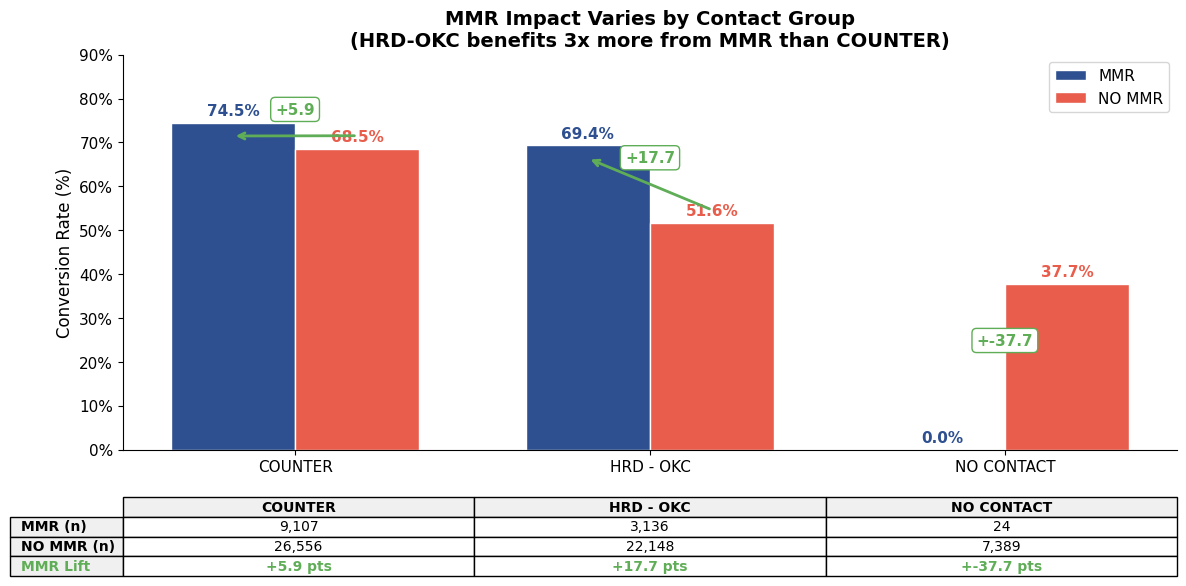


KEY INSIGHT: MMR impact is 3x larger for HRD-OKC
  • HRD-OKC: +17.7 pts lift from MMR
  • COUNTER: +5.9 pts lift from MMR
  • With MMR, HRD-OKC (69.4%) nearly matches COUNTER (74.5%)


In [7]:
# Analysis 2: MMR Impact by Contact Group
# ============================================================

# Calculate MMR impact by contact group
groups = ['COUNTER', 'HRD - OKC', 'NO CONTACT']
mmr_by_group = []

for group in groups:
    mmr_data = df[(df[CONTACT_GROUP] == group) & (df[MMR] == 'MMR')]
    no_mmr_data = df[(df[CONTACT_GROUP] == group) & (df[MMR] == 'NO MMR')]
    
    mmr_by_group.append({
        'group': group,
        'mmr_n': len(mmr_data),
        'mmr_conv': mmr_data[RENT_IND].mean() * 100 if len(mmr_data) > 0 else 0,
        'no_mmr_n': len(no_mmr_data),
        'no_mmr_conv': no_mmr_data[RENT_IND].mean() * 100 if len(no_mmr_data) > 0 else 0,
    })

mmr_by_group_df = pd.DataFrame(mmr_by_group)
mmr_by_group_df['lift'] = mmr_by_group_df['mmr_conv'] - mmr_by_group_df['no_mmr_conv']

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(mmr_by_group_df))
width = 0.35

# Bars
bars1 = ax.bar(x - width/2, mmr_by_group_df['mmr_conv'], width, 
               label='MMR', color=COLORS['mmr'], edgecolor='white')
bars2 = ax.bar(x + width/2, mmr_by_group_df['no_mmr_conv'], width, 
               label='NO MMR', color=COLORS['no_mmr'], edgecolor='white')

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, 
            fontweight='bold', color=COLORS['mmr'])
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11,
            fontweight='bold', color=COLORS['no_mmr'])

# Add lift annotations
for i, (xi, lift) in enumerate(zip(x, mmr_by_group_df['lift'])):
    # Arrow between bars
    ax.annotate('', xy=(xi - width/2, mmr_by_group_df.iloc[i]['mmr_conv'] - 3),
                xytext=(xi + width/2, mmr_by_group_df.iloc[i]['no_mmr_conv'] + 3),
                arrowprops=dict(arrowstyle='->', color=COLORS['tertiary'], lw=2))
    ax.text(xi, (mmr_by_group_df.iloc[i]['mmr_conv'] + mmr_by_group_df.iloc[i]['no_mmr_conv'])/2 + 5,
            f'+{lift:.1f}', ha='center', fontsize=11, fontweight='bold', 
            color=COLORS['tertiary'],
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORS['tertiary']))

# Formatting
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('MMR Impact Varies by Contact Group\n(HRD-OKC benefits 3x more from MMR than COUNTER)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylim(0, 90)
ax.yaxis.set_major_formatter(FuncFormatter(format_pct))
ax.legend(loc='upper right', fontsize=11)

# Data table
table_data = [
    [f"{int(n):,}" for n in mmr_by_group_df['mmr_n']],
    [f"{int(n):,}" for n in mmr_by_group_df['no_mmr_n']],
    [f"+{l:.1f} pts" for l in mmr_by_group_df['lift']]
]
row_labels = ['MMR (n)', 'NO MMR (n)', 'MMR Lift']

table = ax.table(cellText=table_data, rowLabels=row_labels,
                 colLabels=groups,
                 loc='bottom', bbox=[0.0, -0.32, 1.0, 0.2],
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
for key, cell in table.get_celld().items():
    if key[0] == 0 or key[1] == -1:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#f0f0f0')
    if key[0] == 3:  # Lift row
        cell.set_text_props(color=COLORS['tertiary'], fontweight='bold')

plt.subplots_adjust(bottom=0.22)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: MMR impact is 3x larger for HRD-OKC")
print("  • HRD-OKC: +17.7 pts lift from MMR")
print("  • COUNTER: +5.9 pts lift from MMR")
print("  • With MMR, HRD-OKC (69.4%) nearly matches COUNTER (74.5%)")
print("="*70)

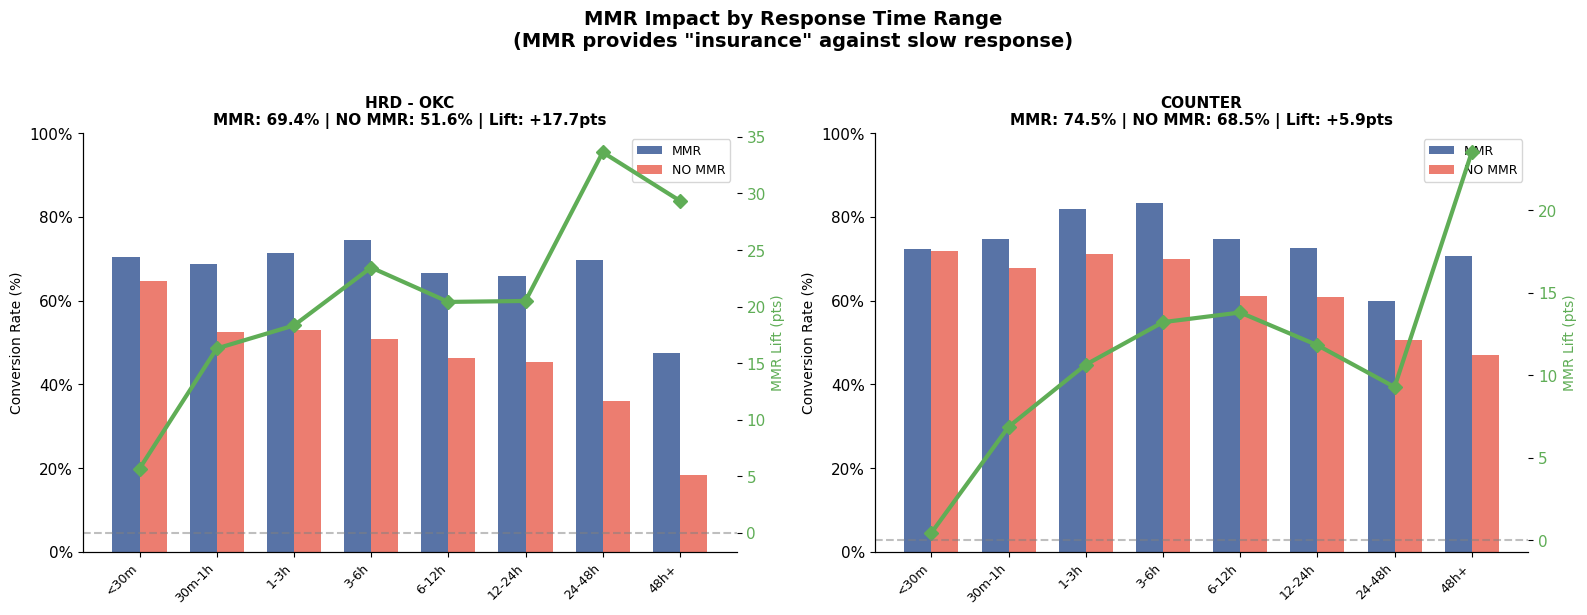


KEY INSIGHT: MMR acts as 'insurance' against slow response times
  • HRD-OKC + NO MMR + 48hrs: Only 18% conversion
  • HRD-OKC + MMR + 48hrs: 48% conversion (+30 pts lift!)
  • MMR lift is largest at longer response times


In [8]:
# Analysis 2: MMR vs NO MMR by Response Time (HRD-OKC Focus)
# ============================================================

def create_mmr_comparison_by_range(df, group_name, ax):
    """Create MMR vs NO MMR comparison chart by response time range."""
    group_df = df[df[CONTACT_GROUP] == group_name]
    mmr_df = group_df[group_df[MMR] == 'MMR']
    no_mmr_df = group_df[group_df[MMR] == 'NO MMR']
    
    results = []
    for range_val in RANGE_ORDER[:-1]:
        mmr_data = mmr_df[mmr_df[CONTACT_RANGE] == range_val]
        no_mmr_data = no_mmr_df[no_mmr_df[CONTACT_RANGE] == range_val]
        
        results.append({
            'range': range_val,
            'mmr_n': len(mmr_data),
            'mmr_conv': mmr_data[RENT_IND].mean() * 100 if len(mmr_data) > 0 else np.nan,
            'no_mmr_n': len(no_mmr_data),
            'no_mmr_conv': no_mmr_data[RENT_IND].mean() * 100 if len(no_mmr_data) > 0 else np.nan,
        })
    
    result_df = pd.DataFrame(results)
    result_df['lift'] = result_df['mmr_conv'] - result_df['no_mmr_conv']
    
    x = np.arange(len(result_df))
    width = 0.35
    
    # Bars
    bars1 = ax.bar(x - width/2, result_df['mmr_conv'], width, 
                   label='MMR', color=COLORS['mmr'], alpha=0.8)
    bars2 = ax.bar(x + width/2, result_df['no_mmr_conv'], width, 
                   label='NO MMR', color=COLORS['no_mmr'], alpha=0.8)
    
    # Lift line on secondary axis
    ax2 = ax.twinx()
    valid_mask = ~result_df['lift'].isna()
    ax2.plot(x[valid_mask], result_df['lift'][valid_mask], 
             color=COLORS['tertiary'], linewidth=3, marker='D', markersize=7,
             label='MMR Lift')
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_ylabel('MMR Lift (pts)', color=COLORS['tertiary'], fontsize=10)
    ax2.tick_params(axis='y', labelcolor=COLORS['tertiary'])
    
    # Formatting
    ax.set_ylabel('Conversion Rate (%)', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(RANGE_LABELS[:-1], rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(FuncFormatter(format_pct))
    
    # Overall stats for title
    mmr_overall = mmr_df[RENT_IND].mean() * 100
    no_mmr_overall = no_mmr_df[RENT_IND].mean() * 100
    ax.set_title(f'{group_name}\nMMR: {mmr_overall:.1f}% | NO MMR: {no_mmr_overall:.1f}% | Lift: +{mmr_overall-no_mmr_overall:.1f}pts',
                 fontsize=11, fontweight='bold')
    
    return result_df

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MMR Impact by Response Time Range\n(MMR provides "insurance" against slow response)', 
             fontsize=14, fontweight='bold', y=1.02)

# HRD-OKC (where MMR matters most)
hrd_mmr_data = create_mmr_comparison_by_range(df, 'HRD - OKC', axes[0])
axes[0].legend(loc='upper right', fontsize=9)

# COUNTER (smaller but still positive MMR impact)
counter_mmr_data = create_mmr_comparison_by_range(df, 'COUNTER', axes[1])
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: MMR acts as 'insurance' against slow response times")
print("  • HRD-OKC + NO MMR + 48hrs: Only 18% conversion")
print("  • HRD-OKC + MMR + 48hrs: 48% conversion (+30 pts lift!)")
print("  • MMR lift is largest at longer response times")
print("="*70)

### Result - Analysis 2

**Overall MMR Impact:**
| MMR Status | Records | Conversion |
|------------|---------|------------|
| MMR | 12,267 | **73.0%** |
| NO MMR | 56,093 | **57.8%** |
| Difference | | **+15.2 pts** |

**MMR Impact by Contact Group:**
| Contact Group | MMR Conv | NO MMR Conv | Diff |
|--------------|----------|-------------|------|
| COUNTER | 74.5% | 68.5% | +5.9 pts |
| HRD - OKC | 69.4% | 51.6% | **+17.7 pts** |

### Key Insights

1. **MMR significantly boosts conversion** by +15.2 pts overall
2. **MMR impact is 3x larger for HRD-OKC** (+17.7 pts) vs COUNTER (+5.9 pts)
3. **With MMR, HRD-OKC nearly matches COUNTER**: 69.4% vs 74.5%
4. **Worst case: HRD-OKC + NO MMR + 48+ hrs** = only 18.3% conversion
5. **Best case: COUNTER + MMR + 3-6 hrs** = 83.3% conversion

---
## Analysis 3: Controlling for MMR - Is COUNTER's Advantage Real?

### Hypothesis
COUNTER's higher conversion rate might be driven by having a higher proportion of MMR records rather than actual performance difference.

### Summary Approach
1. Compare MMR composition between COUNTER and HRD-OKC
2. Calculate conversion rates within each MMR segment (apples-to-apples)
3. Standardize both groups to the same MMR mix
4. Decompose the gap into "due to MMR mix" vs "true performance difference"

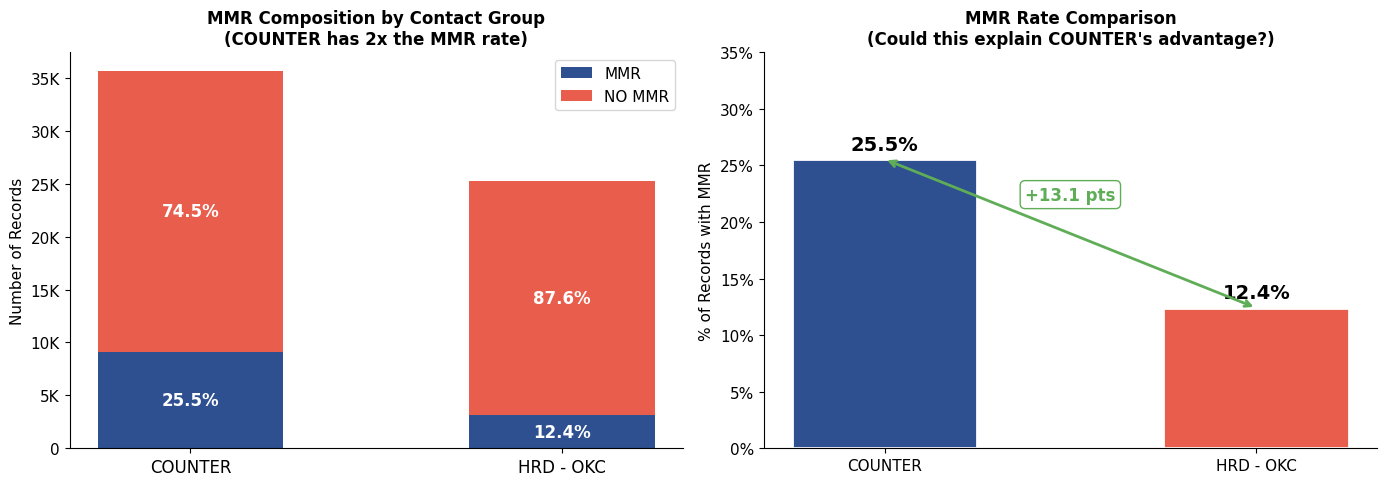


QUESTION: COUNTER has 25.5% MMR vs HRD-OKC has 12.4% MMR
          Does this MMR composition difference explain the gap?
          Let's control for MMR and find out...


In [9]:
# Analysis 3: MMR Composition - Is COUNTER's Advantage Due to More MMR?
# ============================================================

# Calculate MMR composition
counter = df[df[CONTACT_GROUP] == 'COUNTER']
hrd_okc = df[df[CONTACT_GROUP] == 'HRD - OKC']

composition_data = pd.DataFrame({
    'group': ['COUNTER', 'HRD - OKC'],
    'total': [len(counter), len(hrd_okc)],
    'mmr_n': [(counter[MMR] == 'MMR').sum(), (hrd_okc[MMR] == 'MMR').sum()],
    'no_mmr_n': [(counter[MMR] == 'NO MMR').sum(), (hrd_okc[MMR] == 'NO MMR').sum()],
})
composition_data['mmr_pct'] = composition_data['mmr_n'] / composition_data['total'] * 100
composition_data['no_mmr_pct'] = composition_data['no_mmr_n'] / composition_data['total'] * 100

# Create stacked bar chart showing composition
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Stacked bar showing MMR composition
x = np.arange(2)
width = 0.5

bars1 = ax1.bar(x, composition_data['mmr_n'], width, label='MMR', color=COLORS['mmr'])
bars2 = ax1.bar(x, composition_data['no_mmr_n'], width, bottom=composition_data['mmr_n'], 
                label='NO MMR', color=COLORS['no_mmr'])

# Add percentage labels
for i, (mmr_pct, no_mmr_pct) in enumerate(zip(composition_data['mmr_pct'], composition_data['no_mmr_pct'])):
    # MMR percentage
    ax1.text(i, composition_data.iloc[i]['mmr_n']/2, f'{mmr_pct:.1f}%', 
             ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    # NO MMR percentage
    ax1.text(i, composition_data.iloc[i]['mmr_n'] + composition_data.iloc[i]['no_mmr_n']/2, 
             f'{no_mmr_pct:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

ax1.set_xticks(x)
ax1.set_xticklabels(composition_data['group'], fontsize=12)
ax1.set_ylabel('Number of Records', fontsize=11)
ax1.set_title('MMR Composition by Contact Group\n(COUNTER has 2x the MMR rate)', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(FuncFormatter(format_thousands))
ax1.legend(loc='upper right')

# Right: Simple comparison bar showing MMR %
bars = ax2.bar(composition_data['group'], composition_data['mmr_pct'], 
               color=[COLORS['counter'], COLORS['hrd']], width=0.5, edgecolor='white', linewidth=2)

# Add value labels
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add difference annotation
diff = composition_data.iloc[0]['mmr_pct'] - composition_data.iloc[1]['mmr_pct']
ax2.annotate('', xy=(0, composition_data.iloc[0]['mmr_pct']), 
             xytext=(1, composition_data.iloc[1]['mmr_pct']),
             arrowprops=dict(arrowstyle='<->', color=COLORS['tertiary'], lw=2))
ax2.text(0.5, (composition_data.iloc[0]['mmr_pct'] + composition_data.iloc[1]['mmr_pct'])/2 + 3, 
         f'+{diff:.1f} pts', ha='center', fontsize=12, fontweight='bold', 
         color=COLORS['tertiary'],
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORS['tertiary']))

ax2.set_ylabel('% of Records with MMR', fontsize=11)
ax2.set_title('MMR Rate Comparison\n(Could this explain COUNTER\'s advantage?)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 35)
ax2.yaxis.set_major_formatter(FuncFormatter(format_pct))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("QUESTION: COUNTER has 25.5% MMR vs HRD-OKC has 12.4% MMR")
print("          Does this MMR composition difference explain the gap?")
print("          Let's control for MMR and find out...")
print("="*70)

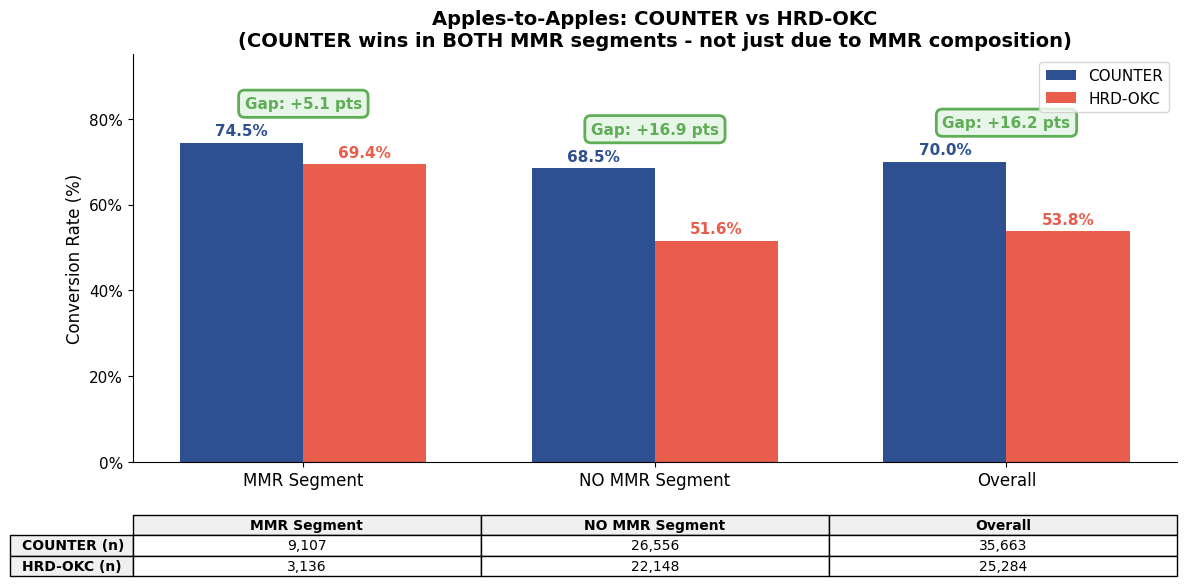


FINDING: COUNTER's advantage is REAL, not due to MMR composition
  • Within MMR only:    COUNTER beats HRD-OKC by +5.1 pts
  • Within NO MMR only: COUNTER beats HRD-OKC by +16.9 pts


In [10]:
# Analysis 3: Apples-to-Apples Comparison (Controlling for MMR)
# ============================================================

# Split data by contact group and MMR
counter_mmr = df[(df[CONTACT_GROUP] == 'COUNTER') & (df[MMR] == 'MMR')]
counter_no_mmr = df[(df[CONTACT_GROUP] == 'COUNTER') & (df[MMR] == 'NO MMR')]
hrd_mmr = df[(df[CONTACT_GROUP] == 'HRD - OKC') & (df[MMR] == 'MMR')]
hrd_no_mmr = df[(df[CONTACT_GROUP] == 'HRD - OKC') & (df[MMR] == 'NO MMR')]

# Calculate conversion rates
conv_rates = {
    'counter_mmr': counter_mmr[RENT_IND].mean() * 100,
    'counter_no_mmr': counter_no_mmr[RENT_IND].mean() * 100,
    'hrd_mmr': hrd_mmr[RENT_IND].mean() * 100,
    'hrd_no_mmr': hrd_no_mmr[RENT_IND].mean() * 100,
    'counter_overall': df[df[CONTACT_GROUP] == 'COUNTER'][RENT_IND].mean() * 100,
    'hrd_overall': df[df[CONTACT_GROUP] == 'HRD - OKC'][RENT_IND].mean() * 100,
}

# Create comparison chart
fig, ax = plt.subplots(figsize=(12, 6))

# Data for grouped bars
categories = ['MMR Segment', 'NO MMR Segment', 'Overall']
counter_vals = [conv_rates['counter_mmr'], conv_rates['counter_no_mmr'], conv_rates['counter_overall']]
hrd_vals = [conv_rates['hrd_mmr'], conv_rates['hrd_no_mmr'], conv_rates['hrd_overall']]
gaps = [c - h for c, h in zip(counter_vals, hrd_vals)]

x = np.arange(len(categories))
width = 0.35

# Bars
bars1 = ax.bar(x - width/2, counter_vals, width, label='COUNTER', color=COLORS['counter'])
bars2 = ax.bar(x + width/2, hrd_vals, width, label='HRD-OKC', color=COLORS['hrd'])

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, 
            fontweight='bold', color=COLORS['counter'])
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11,
            fontweight='bold', color=COLORS['hrd'])

# Add gap annotations with callout boxes
for i, (xi, gap) in enumerate(zip(x, gaps)):
    y_pos = max(counter_vals[i], hrd_vals[i]) + 8
    ax.text(xi, y_pos, f'Gap: +{gap:.1f} pts', ha='center', fontsize=11, fontweight='bold',
            color=COLORS['tertiary'],
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f5e9', edgecolor=COLORS['tertiary'], linewidth=2))

# Formatting
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Apples-to-Apples: COUNTER vs HRD-OKC\n(COUNTER wins in BOTH MMR segments - not just due to MMR composition)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(FuncFormatter(format_pct))
ax.legend(loc='upper right', fontsize=11)

# Add sample sizes as table
table_data = [
    [f"{len(counter_mmr):,}", f"{len(counter_no_mmr):,}", f"{len(counter_mmr)+len(counter_no_mmr):,}"],
    [f"{len(hrd_mmr):,}", f"{len(hrd_no_mmr):,}", f"{len(hrd_mmr)+len(hrd_no_mmr):,}"],
]
row_labels = ['COUNTER (n)', 'HRD-OKC (n)']

table = ax.table(cellText=table_data, rowLabels=row_labels,
                 colLabels=categories,
                 loc='bottom', bbox=[0.0, -0.28, 1.0, 0.15],
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
for key, cell in table.get_celld().items():
    if key[0] == 0 or key[1] == -1:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#f0f0f0')

plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FINDING: COUNTER's advantage is REAL, not due to MMR composition")
print("  • Within MMR only:    COUNTER beats HRD-OKC by +5.1 pts")
print("  • Within NO MMR only: COUNTER beats HRD-OKC by +16.9 pts")
print("="*70)

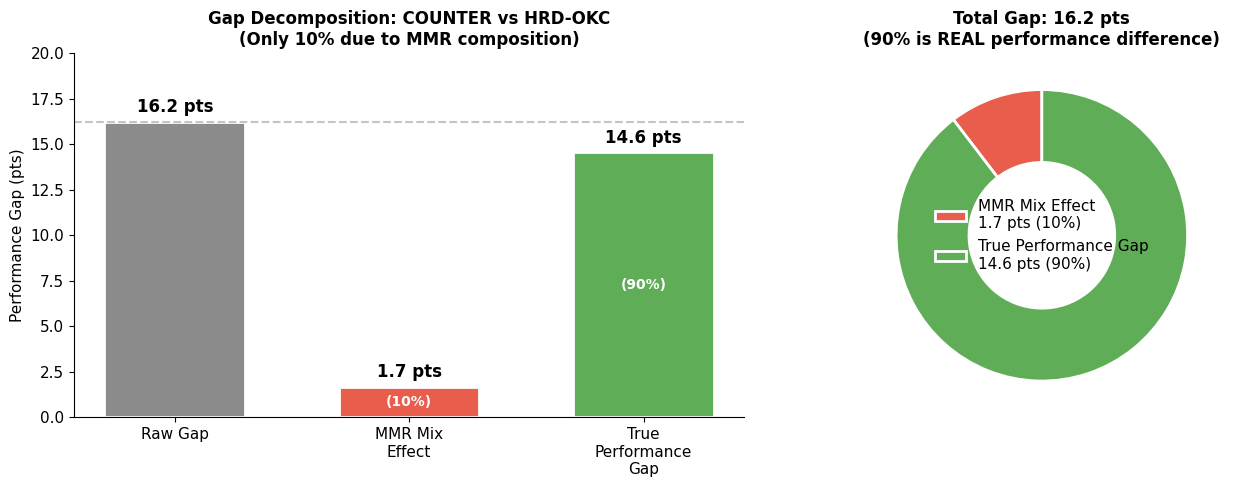


CONCLUSION: COUNTER's advantage is 90% REAL performance
  • Total gap:                    16.2 pts
  • Due to MMR composition:       1.7 pts (10%)
  • True performance difference:  14.6 pts (90%)


In [11]:
# Analysis 3: Gap Decomposition - How Much is Due to MMR Mix?
# ============================================================

# Calculate standardized rates (using overall MMR mix)
contacted = df[df[CONTACT_GROUP].isin(['COUNTER', 'HRD - OKC'])]
overall_mmr_pct = (contacted[MMR] == 'MMR').mean() * 100

# Standardize both groups to the same MMR mix
counter_standardized = (overall_mmr_pct/100 * conv_rates['counter_mmr']) + \
                       ((100-overall_mmr_pct)/100 * conv_rates['counter_no_mmr'])
hrd_standardized = (overall_mmr_pct/100 * conv_rates['hrd_mmr']) + \
                   ((100-overall_mmr_pct)/100 * conv_rates['hrd_no_mmr'])

raw_gap = conv_rates['counter_overall'] - conv_rates['hrd_overall']
adjusted_gap = counter_standardized - hrd_standardized
gap_due_to_mmr = raw_gap - adjusted_gap

# Create waterfall-style visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Waterfall decomposition
categories = ['Raw Gap', 'MMR Mix\nEffect', 'True\nPerformance\nGap']
values = [raw_gap, -gap_due_to_mmr, adjusted_gap]
colors = [COLORS['neutral'], COLORS['no_mmr'], COLORS['tertiary']]

# Calculate positions for waterfall
positions = [raw_gap/2, raw_gap - gap_due_to_mmr/2, adjusted_gap/2]
bottoms = [0, raw_gap, 0]

bars = ax1.bar(categories, [raw_gap, gap_due_to_mmr, adjusted_gap], 
               color=colors, edgecolor='white', linewidth=2, width=0.6)

# Add value labels
for bar, val in zip(bars, [raw_gap, gap_due_to_mmr, adjusted_gap]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{val:.1f} pts', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add percentage labels
pct_mmr = gap_due_to_mmr / raw_gap * 100
pct_real = adjusted_gap / raw_gap * 100
ax1.text(1, gap_due_to_mmr/2, f'({pct_mmr:.0f}%)', ha='center', va='center', 
         fontsize=10, color='white', fontweight='bold')
ax1.text(2, adjusted_gap/2, f'({pct_real:.0f}%)', ha='center', va='center', 
         fontsize=10, color='white', fontweight='bold')

ax1.set_ylabel('Performance Gap (pts)', fontsize=11)
ax1.set_title('Gap Decomposition: COUNTER vs HRD-OKC\n(Only 10% due to MMR composition)', 
              fontsize=12, fontweight='bold')
ax1.set_ylim(0, 20)
ax1.axhline(y=raw_gap, color=COLORS['neutral'], linestyle='--', alpha=0.5)

# Right: Pie chart showing proportion
pie_data = [gap_due_to_mmr, adjusted_gap]
pie_labels = [f'MMR Mix Effect\n{gap_due_to_mmr:.1f} pts ({pct_mmr:.0f}%)', 
              f'True Performance Gap\n{adjusted_gap:.1f} pts ({pct_real:.0f}%)']
pie_colors = [COLORS['no_mmr'], COLORS['tertiary']]

wedges, texts = ax2.pie(pie_data, colors=pie_colors, startangle=90,
                         wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2))

ax2.legend(wedges, pie_labels, loc='center', fontsize=11, frameon=False)
ax2.set_title(f'Total Gap: {raw_gap:.1f} pts\n(90% is REAL performance difference)', 
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CONCLUSION: COUNTER's advantage is 90% REAL performance")
print(f"  • Total gap:                    {raw_gap:.1f} pts")
print(f"  • Due to MMR composition:       {gap_due_to_mmr:.1f} pts ({pct_mmr:.0f}%)")  
print(f"  • True performance difference:  {adjusted_gap:.1f} pts ({pct_real:.0f}%)")
print("="*70)

### Result - Analysis 3

**MMR Composition:**
| Contact Group | % MMR |
|--------------|-------|
| COUNTER | 25.5% |
| HRD - OKC | 12.4% |

COUNTER has 2x the MMR rate (+13.1 pts higher)

**Gap Decomposition:**
```
Total gap (COUNTER - HRD-OKC):              16.2 pts

├── Due to MMR mix difference:               1.7 pts (10%)
│
└── True performance difference:            14.6 pts (90%)  ← REAL GAP
```

### Key Insights

1. **COUNTER's advantage is NOT mainly driven by MMR composition**
2. Only **10% of the gap** (1.7 pts) is explained by COUNTER having more MMR records
3. **90% of the gap** (14.6 pts) represents genuine performance difference
4. Even comparing NO MMR to NO MMR only, COUNTER still beats HRD-OKC by **+16.9 pts**

---
## Analysis 4: Apples-to-Apples Comparison by Time Range (Controlling for MMR)

### Hypothesis
COUNTER's advantage over HRD-OKC persists across all time ranges even when controlling for MMR status.

### Summary Approach
1. Compare COUNTER vs HRD-OKC at each time range within the MMR segment
2. Compare COUNTER vs HRD-OKC at each time range within the NO MMR segment
3. Identify where MMR helps close the gap and where it doesn't

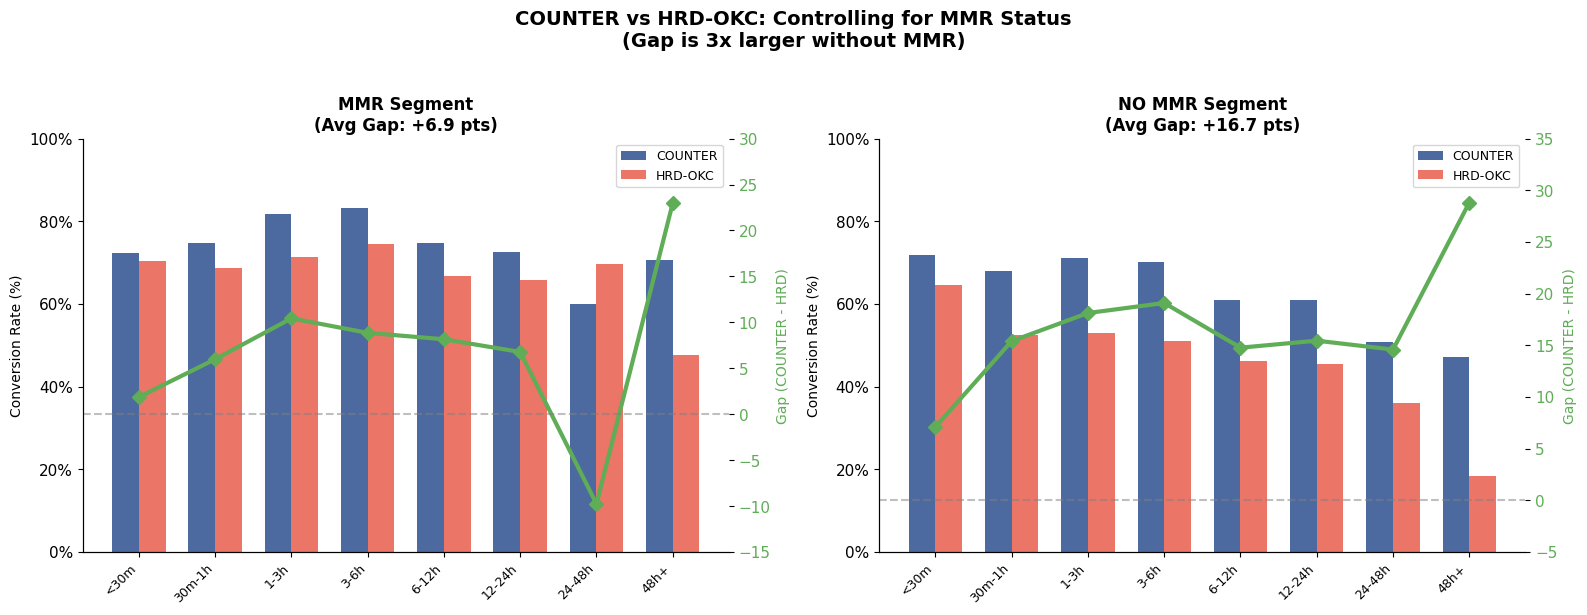


KEY INSIGHT: COUNTER wins at nearly EVERY time range in BOTH segments
  • MMR segment avg gap:    +6.9 pts
  • NO MMR segment avg gap: +16.7 pts (3x larger)


In [12]:
# Analysis 4: COUNTER vs HRD-OKC by Time Range (Controlling for MMR)
# ============================================================

def prepare_controlled_comparison(df, mmr_status):
    """Prepare comparison data controlling for MMR."""
    segment = df[df[MMR] == mmr_status]
    counter = segment[segment[CONTACT_GROUP] == 'COUNTER']
    hrd_okc = segment[segment[CONTACT_GROUP] == 'HRD - OKC']
    
    results = []
    for range_val in RANGE_ORDER[:-1]:
        c_data = counter[counter[CONTACT_RANGE] == range_val]
        h_data = hrd_okc[hrd_okc[CONTACT_RANGE] == range_val]
        
        results.append({
            'range': range_val,
            'counter_n': len(c_data),
            'counter_conv': c_data[RENT_IND].mean() * 100 if len(c_data) > 0 else np.nan,
            'hrd_n': len(h_data),
            'hrd_conv': h_data[RENT_IND].mean() * 100 if len(h_data) > 0 else np.nan,
        })
    
    result_df = pd.DataFrame(results)
    result_df['gap'] = result_df['counter_conv'] - result_df['hrd_conv']
    return result_df

mmr_data = prepare_controlled_comparison(df, 'MMR')
no_mmr_data = prepare_controlled_comparison(df, 'NO MMR')

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('COUNTER vs HRD-OKC: Controlling for MMR Status\n(Gap is 3x larger without MMR)', 
             fontsize=14, fontweight='bold', y=1.02)

def plot_controlled_comparison(data, ax, title, mmr_status):
    x = np.arange(len(data))
    width = 0.35
    
    # Bars
    bars1 = ax.bar(x - width/2, data['counter_conv'], width, 
                   label='COUNTER', color=COLORS['counter'], alpha=0.85)
    bars2 = ax.bar(x + width/2, data['hrd_conv'], width, 
                   label='HRD-OKC', color=COLORS['hrd'], alpha=0.85)
    
    # Gap line on secondary axis
    ax2 = ax.twinx()
    valid_mask = ~data['gap'].isna()
    ax2.plot(x[valid_mask], data['gap'][valid_mask], 
             color=COLORS['tertiary'], linewidth=3, marker='D', markersize=7)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_ylabel('Gap (COUNTER - HRD)', color=COLORS['tertiary'], fontsize=10)
    ax2.tick_params(axis='y', labelcolor=COLORS['tertiary'])
    
    # Set y-limits based on data
    if mmr_status == 'MMR':
        ax2.set_ylim(-15, 30)
    else:
        ax2.set_ylim(-5, 35)
    
    # Formatting
    ax.set_ylabel('Conversion Rate (%)', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(RANGE_LABELS[:-1], rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(FuncFormatter(format_pct))
    ax.legend(loc='upper right', fontsize=9)
    
    # Calculate average gap
    avg_gap = data['gap'].mean()
    ax.set_title(f'{title}\n(Avg Gap: +{avg_gap:.1f} pts)', fontsize=12, fontweight='bold')

plot_controlled_comparison(mmr_data, axes[0], 'MMR Segment', 'MMR')
plot_controlled_comparison(no_mmr_data, axes[1], 'NO MMR Segment', 'NO MMR')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: COUNTER wins at nearly EVERY time range in BOTH segments")
print(f"  • MMR segment avg gap:    +{mmr_data['gap'].mean():.1f} pts")
print(f"  • NO MMR segment avg gap: +{no_mmr_data['gap'].mean():.1f} pts (3x larger)")
print("="*70)

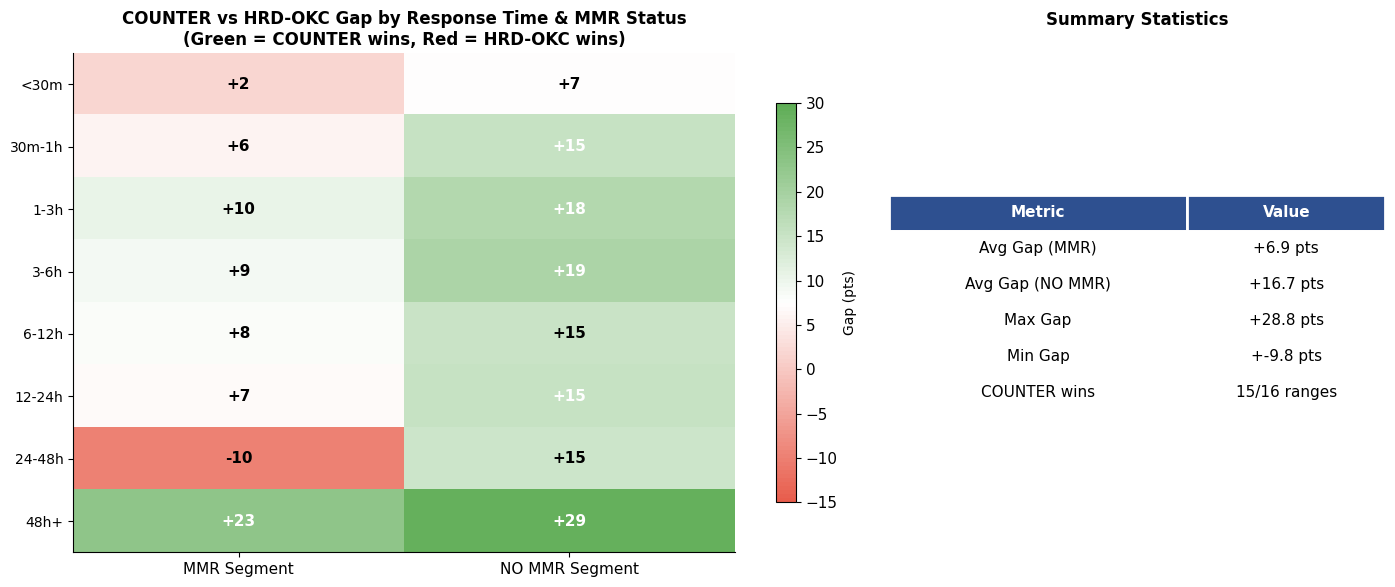


PATTERN: Gap widens as response time increases
  • Fast response (<30min): Gap is smallest (+2 to +7 pts)
  • Slow response (48+hrs): Gap is largest (+23 to +29 pts)
  • MMR helps close the gap but doesn't eliminate it


In [13]:
# Analysis 4: Summary Heat Map - Gap Analysis
# ============================================================

# Prepare summary data for heat map
summary_data = []
for i, range_val in enumerate(RANGE_ORDER[:-1]):
    mmr_gap = mmr_data.iloc[i]['gap'] if i < len(mmr_data) else np.nan
    no_mmr_gap = no_mmr_data.iloc[i]['gap'] if i < len(no_mmr_data) else np.nan
    summary_data.append({
        'range': RANGE_LABELS[i],
        'MMR Gap': mmr_gap,
        'NO MMR Gap': no_mmr_gap
    })

summary_df = pd.DataFrame(summary_data).set_index('range')

# Create heat map style visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})

# Left: Heat map of gaps
import matplotlib.colors as mcolors

# Create a custom colormap (red for negative, white for zero, green for positive)
colors_list = ['#E85D4C', '#ffffff', '#5FAD56']
n_bins = 100
cmap = mcolors.LinearSegmentedColormap.from_list('custom', colors_list, N=n_bins)

# Plot heat map
im = ax1.imshow(summary_df.values, cmap=cmap, aspect='auto', vmin=-15, vmax=30)

# Add text annotations
for i in range(len(summary_df)):
    for j in range(len(summary_df.columns)):
        val = summary_df.iloc[i, j]
        if not np.isnan(val):
            text_color = 'white' if abs(val) > 15 else 'black'
            ax1.text(j, i, f'+{val:.0f}' if val > 0 else f'{val:.0f}', 
                    ha='center', va='center', fontsize=11, fontweight='bold', color=text_color)

ax1.set_xticks(np.arange(len(summary_df.columns)))
ax1.set_xticklabels(['MMR Segment', 'NO MMR Segment'], fontsize=11)
ax1.set_yticks(np.arange(len(summary_df)))
ax1.set_yticklabels(summary_df.index, fontsize=10)
ax1.set_title('COUNTER vs HRD-OKC Gap by Response Time & MMR Status\n(Green = COUNTER wins, Red = HRD-OKC wins)', 
              fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax1, shrink=0.8)
cbar.set_label('Gap (pts)', fontsize=10)

# Right: Summary statistics
stats_data = {
    'Metric': ['Avg Gap (MMR)', 'Avg Gap (NO MMR)', 'Max Gap', 'Min Gap', 'COUNTER wins'],
    'Value': [
        f"+{mmr_data['gap'].mean():.1f} pts",
        f"+{no_mmr_data['gap'].mean():.1f} pts",
        f"+{max(mmr_data['gap'].max(), no_mmr_data['gap'].max()):.1f} pts",
        f"+{min(mmr_data['gap'].min(), no_mmr_data['gap'].min()):.1f} pts",
        f"{((mmr_data['gap'] > 0).sum() + (no_mmr_data['gap'] > 0).sum())}/16 ranges"
    ]
}
stats_df = pd.DataFrame(stats_data)

ax2.axis('off')
table = ax2.table(cellText=stats_df.values, colLabels=stats_df.columns,
                  loc='center', cellLoc='center',
                  colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white')
    cell.set_edgecolor('white')
    cell.set_linewidth(2)

ax2.set_title('Summary Statistics', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PATTERN: Gap widens as response time increases")
print("  • Fast response (<30min): Gap is smallest (+2 to +7 pts)")
print("  • Slow response (48+hrs): Gap is largest (+23 to +29 pts)")
print("  • MMR helps close the gap but doesn't eliminate it")
print("="*70)

### Result - Analysis 4

**MMR Segment: COUNTER vs HRD-OKC Gap**

| Range | COUNTER | HRD-OKC | Gap |
|-------|---------|---------|-----|
| <30 min | 72.2% | 70.4% | **+1.9%** |
| 31 min - 1 hr | 74.7% | 68.8% | +6.0% |
| 1-3 hrs | 81.9% | 71.4% | +10.4% |
| 3-6 hrs | 83.3% | 74.4% | +8.9% |
| 6-12 hrs | 74.8% | 66.7% | +8.2% |
| 12-24 hrs | 72.7% | 65.9% | +6.8% |
| 24-48 hrs | 60.0% | 69.8% | -9.8% |
| 48+ hrs | 70.6% | 47.6% | +23.0% |
| **TOTAL** | **74.5%** | **69.4%** | **+5.1%** |

**NO MMR Segment: COUNTER vs HRD-OKC Gap**

| Range | COUNTER | HRD-OKC | Gap |
|-------|---------|---------|-----|
| <30 min | 71.8% | 64.7% | +7.1% |
| 31 min - 1 hr | 67.9% | 52.5% | +15.4% |
| 1-3 hrs | 71.2% | 53.1% | **+18.1%** |
| 3-6 hrs | 70.1% | 51.0% | **+19.1%** |
| 6-12 hrs | 61.0% | 46.2% | +14.8% |
| 12-24 hrs | 60.9% | 45.4% | +15.4% |
| 24-48 hrs | 50.7% | 36.1% | +14.6% |
| 48+ hrs | 47.1% | 18.3% | **+28.8%** |
| **TOTAL** | **68.5%** | **51.6%** | **+16.9%** |

### Key Insights

1. **COUNTER wins at almost every time range** in both MMR segments
2. **Gap is 3x larger without MMR**: +5.1 pts (MMR) vs +16.9 pts (NO MMR)
3. **MMR nearly equalizes at <30 min**: Gap shrinks from +7.1 to +1.9 pts
4. **HRD-OKC collapses without MMR at slow response**: 48+ hrs = only 18.3%
5. **Fast response + MMR** can make HRD-OKC nearly as effective as COUNTER

---
## Executive Summary

### Overall Findings

| Metric | COUNTER | HRD-OKC | NO CONTACT |
|--------|---------|---------|------------|
| Records | 35,663 | 25,284 | 7,413 |
| Conversion | **70.0%** | **53.8%** | **37.6%** |

### Key Conclusions

1. **Contact matters**: Being contacted (COUNTER or HRD-OKC) significantly beats NO CONTACT

2. **COUNTER outperforms HRD-OKC** by 16.2 pts, and this is **90% real performance difference** (not driven by MMR composition)

3. **Speed matters**: Faster response = higher conversion, especially for HRD-OKC

4. **MMR boosts conversion**: +15.2 pts overall, with 3x larger impact on HRD-OKC

5. **Best scenario**: COUNTER + MMR + 1-6 hrs = ~82% conversion

6. **Worst scenario**: HRD-OKC + NO MMR + 48+ hrs = only 18.3% conversion

### Recommendations

1. **Reduce NO CONTACT rate** - Every contact attempt has significant value
2. **For HRD-OKC**: Prioritize response time <30 min where gap with COUNTER is smallest
3. **Ensure MMR coverage** especially for slower response scenarios
4. **Investigate COUNTER processes** to identify transferable best practices